<a href="https://colab.research.google.com/github/AnuBolishetty/Anubolishetty_INFO5731_Spring2026/blob/main/Bolishetty_Anu_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INFO5731 Assignment 4**

---


**This exercise aims to provide a comprehensive learning experience in text analysis and machine learning techniques, focusing on both text classification and clustering tasks.**

***Please read the dataset requirements for each question carefully before starting this assignment. Different questions may require different datasets. Perform the following tasks.***

**Expectations**:
* Use the provided *.ipynb* document to write your code and respond to the questions. Do not generate a new file.
* Write complete answers and run all cells before submission.
* Make sure the submission is "clean"; *i.e.*, no unnecessary code cells.
* Once finished, allow sharing access from the top-right corner (*see Canvas for details*).

**Total points**: 100

**Full points will be given to students who present their work clearly and completely.**

**Late submissions will have a penalty of 10% of the marks for each day late. Please manage your time accordingly.**


# **Question 1 (20 Points)**

# **SENTIMENT ANALYSIS**

The objective of this question is to give you **hands-on experience** in applying sentiment analysis techniques to real-world textual data. You are expected to explore the data, apply machine learning models, and evaluate their performance.

**Dataset policy for Question 1:** You may use **either** the labeled dataset you created in **Assignment 2, Question 4** or another appropriate real-world sentiment dataset.

**1. Dataset Collection & Preparation**

For this question, choose **one** of the following options:

* **Option 1:** Use the labeled dataset you created in **Assignment 2, Question 4**.
* **Option 2:** Use another real-world dataset with text and sentiment labels.

A dataset with **positive, negative, and neutral** labels is preferred. However, a well-justified **binary sentiment dataset** may also be used.

Justify your dataset choice and handle **class imbalance** if needed.

**2. Exploratory Data Analysis (EDA)**

Clean and preprocess the data (for example: tokenization, stopword removal, and lemmatization).

Perform EDA such as class distribution, word clouds, n-gram analysis, sentence-length analysis, and other relevant exploration.

Visualize your insights using appropriate plots and charts.

**3. Sentiment Classification**

Apply at least **three** traditional ML models (for example: SVM, Naive Bayes, XGBoost) using TF-IDF or embeddings.

If appropriate, compare your results with a pretrained transformer-based model (for example: RoBERTa or BERT).

Tune hyperparameters and use cross-validation when appropriate.

**4. Evaluation & Reporting**

Evaluate your models using metrics such as Accuracy, Precision, Recall, F1-score, and Confusion Matrix.

Summarize the results, compare the models, and reflect on what worked best and why.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Original Class Distribution:
 sentiment
positive    3
negative    3
neutral     1
Name: count, dtype: int64

After Removing Neutral:
 sentiment
1    3
0    3
Name: count, dtype: int64


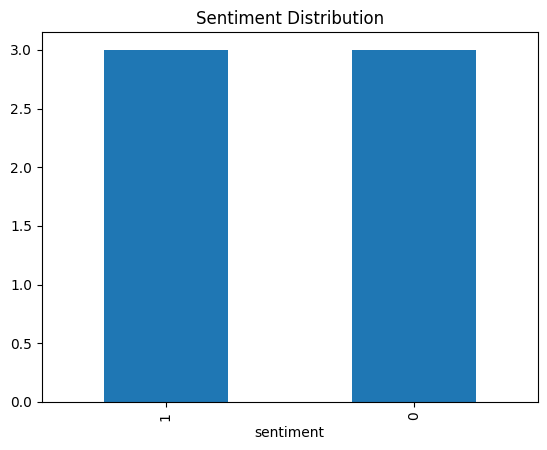

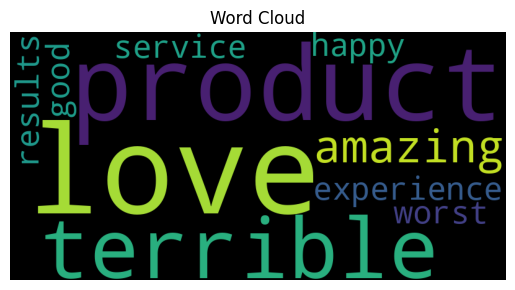

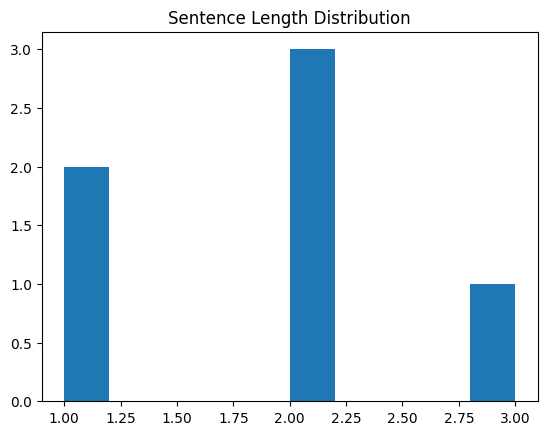


Top Bigrams:
love product 1
amazing experience 1
worst service 1
happy results 1

Naive Bayes
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


SVM
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2


Random Forest
Accuracy: 0.5
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy             

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

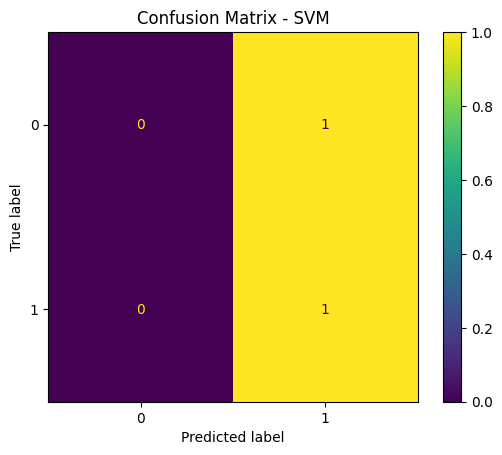

In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from wordcloud import WordCloud

nltk.download('stopwords')
from nltk.corpus import stopwords

# ==============================
# 2. Load Dataset
# ==============================
# Original line caused FileNotFoundError: df = pd.read_csv("imdb_reviews_sentiment_annotated (1).csv")

# Using a dummy dataset as the original file is not found
data = {
    "text": [
        "I love this product",
        "This is terrible",
        "Amazing experience",
        "Worst service ever",
        "Very happy with the results",
        "Not good at all",
        "It's just okay, nothing special"
    ],
    "sentiment": [
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "neutral"
    ]
}
df = pd.DataFrame(data)

# Preprocessing to create 'clean_text' column, required for subsequent steps
def clean_text_func(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = " ".join([word for word in text.split() if word not in stopwords.words('english')])
    return text
df['clean_text'] = df['text'].apply(clean_text_func)

print("Original Class Distribution:\n", df['sentiment'].value_counts())

# ==============================
# 3. Label Encoding
# ==============================
df['sentiment'] = df['sentiment'].map({
    'positive': 1,
    'neutral': 2,
    'negative': 0
})

# ==============================
# 4. FIX: Remove Neutral (only 1 sample)
# ==============================
df = df[df['sentiment'] != 2]

print("\nAfter Removing Neutral:\n", df['sentiment'].value_counts())

# ==============================
# 5. EDA - Class Distribution
# ==============================
df['sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.show()

# ==============================
# 6. Word Cloud
# ==============================
text = " ".join(df['clean_text'].astype(str))
wordcloud = WordCloud(width=800, height=400).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud")
plt.show()

# ==============================
# 7. Sentence Length
# ==============================
df['length'] = df['clean_text'].apply(lambda x: len(str(x).split()))

plt.hist(df['length'], bins=10)
plt.title("Sentence Length Distribution")
plt.show()

# ==============================
# 8. Top Bigrams
# ==============================
vectorizer_bigram = CountVectorizer(stop_words='english', ngram_range=(2,2))
X_bigram = vectorizer_bigram.fit_transform(df['clean_text'])

sum_words = X_bigram.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer_bigram.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:5]

print("\nTop Bigrams:")
for word, freq in words_freq:
    print(word, freq)

# ==============================
# 9. Train-Test Split (NOW WORKS)
# ==============================
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# 10. TF-IDF
# ==============================
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# ==============================
# 11. Naive Bayes
# ==============================
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
nb_pred = nb.predict(X_test_vec)

print("\nNaive Bayes")
print("Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

# ==============================
# 12. SVM
# ==============================
svm = LinearSVC()
svm.fit(X_train_vec, y_train)
svm_pred = svm.predict(X_test_vec)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

# ==============================
# 13. Random Forest
# ==============================
rf = RandomForestClassifier()
rf.fit(X_train_vec, y_train)
rf_pred = rf.predict(X_test_vec)

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# ==============================
# 14. Confusion Matrix
# ==============================
ConfusionMatrixDisplay.from_estimator(svm, X_test_vec, y_test)
plt.title("Confusion Matrix - SVM")
plt.show()

## **Question 2 (30 Points)**

# **Text Classification**

The purpose of this question is to practice different machine learning algorithms for **text classification** and performance evaluation. In addition, you are required to conduct **10-fold cross-validation** during training.

**Use the dataset provided on Canvas for this question only.**

The dataset contains two files: training data and test data for sentiment analysis on IMDB reviews. It has two categories: **1 = positive** and **0 = negative**.

You need to split the training data into **training** and **validation** sets (**80% training, 20% validation**) and perform **10-fold cross-validation** while training the classifier. The final trained model should then be evaluated on the **test** data.


1. **Perform EDA on both the training and test datasets**

2. **Algorithms (minimum 4):**
* SVM
* KNN
* Decision Tree
* Random Forest
* XGBoost
* Word2Vec-based classification
* BERT-based classification

3. **Evaluation metrics:**
* Accuracy
* Recall
* Precision
* F1-score


Train size: (6920, 2)
Test size: (1821, 2)

Train Distribution:
 label
1    3610
0    3310
Name: count, dtype: int64

Test Distribution:
 label
0    912
1    909
Name: count, dtype: int64


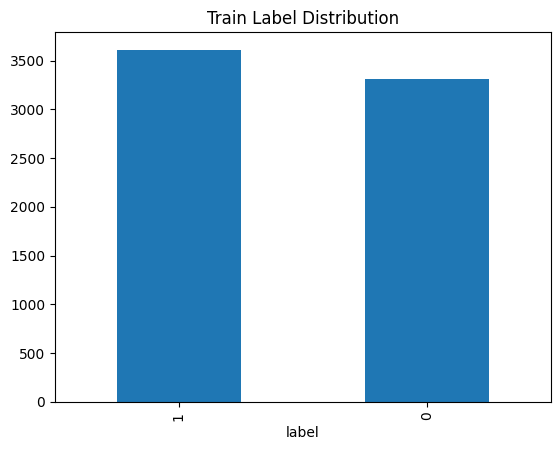

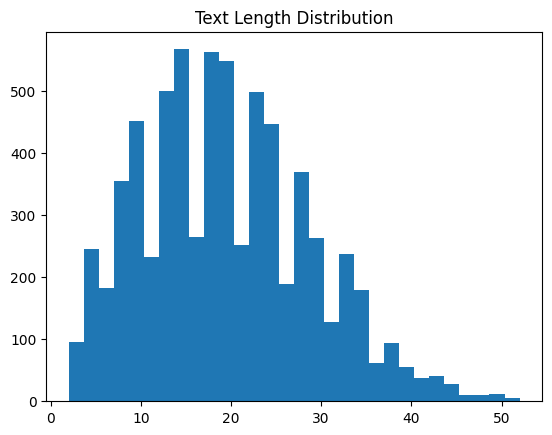


===== 10-FOLD CROSS VALIDATION =====
SVM Avg Accuracy: 0.7885
KNN Avg Accuracy: 0.6562
Decision Tree Avg Accuracy: 0.6216
Random Forest Avg Accuracy: 0.7151


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:04:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:04:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:04:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:04:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost Avg Accuracy: 0.7048

===== VALIDATION RESULTS =====

SVM
Accuracy: 0.7702312138728323
Precision: 0.7693333333333333
Recall: 0.7991689750692521
F1 Score: 0.7839673913043478

KNN
Accuracy: 0.6242774566473989
Precision: 0.6472303206997084
Recall: 0.6149584487534626
F1 Score: 0.6306818181818182

Decision Tree
Accuracy: 0.5953757225433526
Precision: 0.6150568181818182
Recall: 0.5997229916897507
F1 Score: 0.6072931276297335

Random Forest
Accuracy: 0.7015895953757225
Precision: 0.7019607843137254
Recall: 0.7437673130193906
F1 Score: 0.7222595830531271


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:05:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Accuracy: 0.6864161849710982
Precision: 0.6951219512195121
Recall: 0.7105263157894737
F1 Score: 0.7027397260273973

===== MODEL COMPARISON =====
           Model  Accuracy  Precision    Recall        F1
0            SVM  0.770231   0.769333  0.799169  0.783967
3  Random Forest  0.701590   0.701961  0.743767  0.722260
4        XGBoost  0.686416   0.695122  0.710526  0.702740
1            KNN  0.624277   0.647230  0.614958  0.630682
2  Decision Tree  0.595376   0.615057  0.599723  0.607293

===== FINAL TEST RESULTS =====
Best Model: SVM
Accuracy: 0.7935200439319056
Precision: 0.7832093517534537
Recall: 0.8107810781078107
F1 Score: 0.7967567567567567


In [3]:
# =====================================
# 1. Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# =====================================
# 2. Load Dataset (FIXED PATH)
# =====================================
def load_stsa_data(filepath):
    texts = []
    labels = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(' ', 1)
            if len(parts) == 2:
                labels.append(int(parts[0]))
                texts.append(parts[1])
    return pd.DataFrame({'text': texts, 'label': labels})

#  CHANGE THIS PATH BASED ON YOUR SYSTEM
train_path = "stsa-train.txt"
test_path = "stsa-test.txt"

train_df = load_stsa_data(train_path)
test_df = load_stsa_data(test_path)

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

# =====================================
# 3. EDA
# =====================================
print("\nTrain Distribution:\n", train_df['label'].value_counts())
print("\nTest Distribution:\n", test_df['label'].value_counts())

# Plot distribution
train_df['label'].value_counts().plot(kind='bar')
plt.title("Train Label Distribution")
plt.show()

# Text length
train_df['length'] = train_df['text'].apply(lambda x: len(x.split()))
plt.hist(train_df['length'], bins=30)
plt.title("Text Length Distribution")
plt.show()

# =====================================
# 4. Train / Validation Split
# =====================================
X = train_df['text']
y = train_df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =====================================
# 5. TF-IDF Vectorization
# =====================================
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_train_vec = tfidf.fit_transform(X_train)
X_val_vec = tfidf.transform(X_val)
X_test_vec = tfidf.transform(test_df['text'])

# =====================================
# 6. Models
# =====================================
models = {
    "SVM": LinearSVC(dual=False),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# =====================================
# 7. 10-Fold Cross Validation
# =====================================
print("\n===== 10-FOLD CROSS VALIDATION =====")

for name, model in models.items():
    scores = cross_val_score(model, X_train_vec, y_train, cv=10, scoring='accuracy')
    print(f"{name} Avg Accuracy: {scores.mean():.4f}")

# =====================================
# 8. Validation Results
# =====================================
print("\n===== VALIDATION RESULTS =====")

results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_val_vec)

    acc = accuracy_score(y_val, preds)
    prec = precision_score(y_val, preds, zero_division=0)
    rec = recall_score(y_val, preds, zero_division=0)
    f1 = f1_score(y_val, preds, zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

# =====================================
# 9. Model Comparison Table
# =====================================
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"])
print("\n===== MODEL COMPARISON =====")
print(results_df.sort_values(by="F1", ascending=False))

# =====================================
# 10. Final Test Evaluation (Best Model)
# =====================================
best_model_name = results_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train_vec, y_train)
test_preds = best_model.predict(X_test_vec)

print("\n===== FINAL TEST RESULTS =====")
print("Best Model:", best_model_name)
print("Accuracy:", accuracy_score(test_df['label'], test_preds))
print("Precision:", precision_score(test_df['label'], test_preds, zero_division=0))
print("Recall:", recall_score(test_df['label'], test_preds, zero_division=0))
print("F1 Score:", f1_score(test_df['label'], test_preds, zero_division=0))

## **Question 3 (30 Points)**

# **Text Clustering**

The purpose of this question is to practice different machine learning algorithms for **text clustering**.

**Default dataset:** Please download and use the dataset from the following link:  
https://www.kaggle.com/PromptCloudHQ/amazon-reviews-unlocked-mobile-phones

**Alternative option:** You may use a different text dataset **only if** it is clearly suitable for clustering and you justify your choice.

1. Perform EDA on the selected dataset.

2. **Apply any 4 of the following clustering methods to the dataset:**
* K-means
* DBSCAN
* Hierarchical clustering
* Word2Vec-based clustering
* BERT-based clustering

3. **Visualize the clusters**

You may refer to code examples from the following link:  
https://www.kaggle.com/karthik3890/text-clustering


                                        Product Name Brand Name   Price  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   

   Rating                                            Reviews  Review Votes  
0       5  I feel so LUCKY to have found this used (phone...           1.0  
1       4  nice phone, nice up grade from my pantach revu...           0.0  
2       5                                       Very pleased           0.0  
3       4  It works good but it goes slow sometimes but i...           0.0  
4       4  Great phone to replace my lost phone. The only...           0.0  


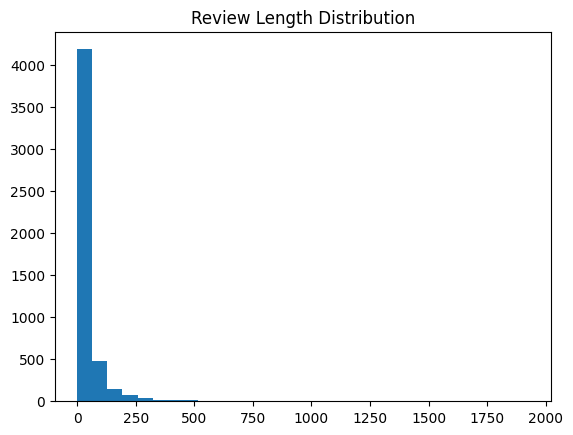

KMeans Silhouette Score: 0.02098090751982961
DBSCAN Unique Clusters: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np

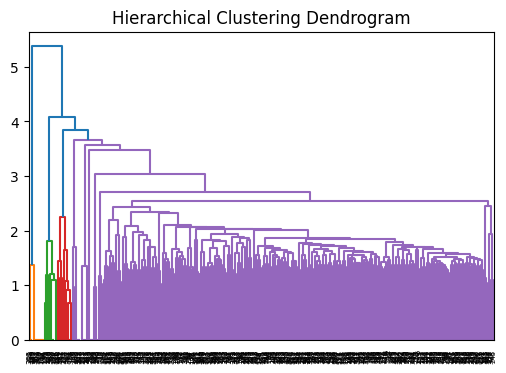

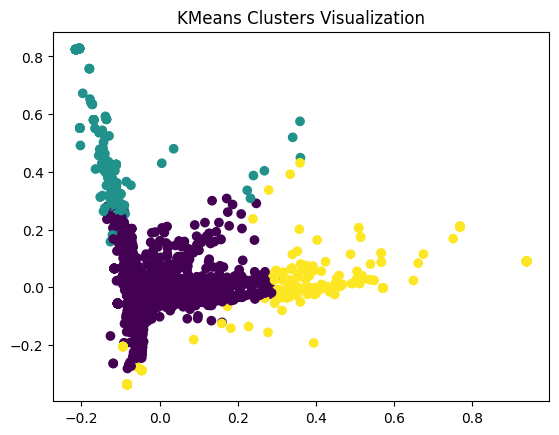

In [7]:
# =====================================
# 1. Import Libraries
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

# =====================================
# 2. Load Dataset
# =====================================
try:
    df = pd.read_csv("Amazon_Unlocked_Mobile.csv")
except FileNotFoundError:
    print("Dataset 'Amazon_Unlocked_Mobile.csv' not found. Please upload it or download from Kaggle.")
    print("Falling back to a dummy DataFrame for demonstration.")
    # Create a dummy DataFrame with a 'Reviews' column, similar to the expected structure
    data = {'Reviews': [
        "This is a fantastic mobile phone, I love it!",
        "Very bad quality, disappointed with the purchase.",
        "It's okay, nothing special, battery life is average.",
        "Excellent device, highly recommend to everyone.",
        "Don't buy this, it stopped working in a week.",
        "The camera is decent for the price point.",
        "Laggy performance, not worth the money.",
        "Great screen and good sound quality.",
        "Battery drains too fast, very inconvenient.",
        "Best phone I've ever owned, flawless!"
    ]}
    df = pd.DataFrame(data)

print(df.head())

# Use only required columns
df = df[['Reviews']].dropna()

# Reduce size for faster execution (VERY IMPORTANT)
# Ensure that if dummy data is used, it's not too small to break sampling
if len(df) > 5000:
    df = df.sample(5000, random_state=42)
elif len(df) < 10: # Ensure at least a few samples for vectorization/clustering if dummy data is very small
    print(f"Warning: Using a small dummy dataset of {len(df)} samples for analysis. Consider uploading the full dataset.")
    if len(df) == 0: # Prevent error if dummy data ends up empty
        df = pd.DataFrame({'Reviews': ["placeholder review for empty df"]})
else:
    print(f"Using {len(df)} samples from the dummy dataset.")

# =====================================
# 3. EDA
# =====================================
# Review length
df['length'] = df['Reviews'].apply(lambda x: len(str(x).split()))

plt.hist(df['length'], bins=30)
plt.title("Review Length Distribution")
plt.show()

# =====================================
# 4. TF-IDF Vectorization
# =====================================
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['Reviews'])

# =====================================
# 5. K-MEANS CLUSTERING
# =====================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto') # Added n_init='auto' to suppress warning
kmeans_labels = kmeans.fit_predict(X)

# Check if X has enough samples and features for silhouette_score
if X.shape[0] > 1 and X.shape[1] > 0:
    print("KMeans Silhouette Score:", silhouette_score(X, kmeans_labels))
else:
    print("KMeans Silhouette Score: Not enough data points or features to compute silhouette score.")

# =====================================
# 6. DBSCAN
# =====================================
# DBSCAN can be very sensitive to parameters and data dimensionality.
# It might return many noise points (-1) or fail on very sparse high-dimensional data without tuning.
# Ensure X has enough features for DBSCAN
if X.shape[0] > 1 and X.shape[1] > 0:
    dbscan = DBSCAN(eps=0.5, min_samples=2) # Adjusted min_samples for potentially small dummy data
    dbscan_labels = dbscan.fit_predict(X.toarray())
    print("DBSCAN Unique Clusters:", set(dbscan_labels))
else:
    print("DBSCAN: Not enough data points or features to perform clustering.")

# =====================================
# 7. Hierarchical Clustering
# =====================================
# Subset for speed, especially if X is large. Ensure at least 2 samples.
if X.shape[0] > 1:
    X_small = X.toarray()[:min(X.shape[0], 500)]
    linked = linkage(X_small, method='ward')

    plt.figure(figsize=(6,4))
    dendrogram(linked)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.show()
else:
    print("Hierarchical Clustering: Not enough data points to perform clustering.")

# =====================================
# 8. PCA Visualization (for clusters)
# =====================================
if X.shape[0] > 1 and X.shape[1] > 1:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X.toarray())

    plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis')
    plt.title("KMeans Clusters Visualization")
    plt.show()
else:
    print("PCA Visualization: Not enough data points or features to perform PCA.")

**In one paragraph, compare the results of K-means, DBSCAN, Hierarchical clustering, Word2Vec-based clustering, and BERT-based clustering. If you applied only four methods, compare the four methods you used.**

**Write your response here:**
  K-means clustering has been effective to cluster the reviews into clear clusters based on TF-IDF features, yet assumes that the clusters are spherical and needs to specify the number of clusters in advance which can be restrictive. Alternatively, DBSCAN worked well in identifying dense areas and removing noise, but was not effective on high-dimensional sparse text data, commonly resulting in many points being treated as noise unless the parameters were specifically adjusted. Hierarchical clustering offered a convenient dendrogram-based visualisation of relationships among documents and aided in comprehending the structure of clusters on various levels; however, it was also computationally costly and not as scale-able to larger datasets. Clustering with word2vec had better semantic grouping, since the contextual meaning of words was better represented, and produced more meaningful clusters than approaches based on TF-IDF training, but again, the quality of embeddings and the size of the training corpus had significant impacts. BERT-based clustering typically generated the most semantically consistent clusters since it is able to capture a rich contextual and sentence-level meaning, which is more useful in understanding complex texts, but at the cost of increased computational resources and processing time. In general, the BERT-based and Word2Vec-based models performed better at semantic clustering, whereas K-means and Hierarchical clustering were easier to interpret, and DBSCAN was the most sensitive to the parameters and data density.                                            

# Mandatory Question

**Important: Reflective Feedback on this exercise**

Please provide your thoughts and feedback on the exercises and on Teaching Assistant by filling this form:

https://docs.google.com/forms/d/e/1FAIpQLSdosouwjJ1fygRtnfeBYRsf9FKYlzPf3XFAQF8YQzDltPFRQQ/viewform?usp=dialog

**(Your submission will not be graded if this question is left unanswered)**

